<a href="https://colab.research.google.com/github/VictorPontual/MLP_Geometry_Classificator/blob/main/classificador_geometrico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificador de Formas Geométricas com PyTorch

## Visão Geral do Projeto

Este projeto mostra como construir um pipeline de aprendizado profundo do zero usando PyTorch. O objetivo é classificar imagens sintéticas de triângulos, círculos e quadrados.

Geramos o conjunto de dados sinteticamente no próprio notebook. Isso nos dá controle total sobre os dados e ajuda a entender cada etapa do PyTorch antes de usar arquiteturas mais complexas.

---

## Objetivos e Habilidades

Neste projeto, aprendemos e desenvolvemos as seguintes habilidades:

1.  **Geração e Organização de Dados:** Criar dados sintéticos e organizá-los.
2.  **Dataset Personalizado com PyTorch:** Criar uma classe `Dataset` personalizada.
3.  **Transformações de Imagem:** Usar `torchvision.transforms` para pré-processar e aumentar os dados.
4.  **Configuração do `DataLoader`:** Otimizar o carregamento de dados.
5.  **Arquitetura de Rede Neural (MLP):** Projetar e implementar um MLP usando `nn.Module`.
6.  **Loop de Treinamento e Validação:** Desenvolver loops de treino e validação.
7.  **Monitoramento de Métricas:** Acompanhar loss e acurácia durante o treinamento.
8.  **Gerenciamento de Modelos:** Salvar e carregar modelos.
9.  **Avaliação de Modelos:** Analisar desempenho com matriz de confusão e relatório de classificação.
10. **Experimentação e Regularização:** Explorar hiperparâmetros e Dropout.

---

## Entregas

-   Este notebook, com todos os resultados visíveis.
-   Um relatório final com:
    -   Escolhas de arquitetura e hiperparâmetros.
    -   Gráficos de treinamento e validação.
    -   Acurácia final no teste.
    -   Análise da matriz de confusão.
    -   Respostas às Questões de Reflexão.

---

## Regras

-   Usar apenas camadas densas (`nn.Linear`), sem convolucionais (`nn.Conv2d`).
-   O código nas células `# TODO` foi implementado como parte deste projeto.
-   Células de exemplo não devem ser alteradas.

In [ ]:
import os
import random
import shutil
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {DEVICE}")
print(f"PyTorch     : {torch.__version__}")

Dispositivo : cuda
PyTorch     : 2.10.0+cu128


---
## Parte 1 — Geração do Dataset Sintético

Vamos criar imagens 64x64 pixels em escala de cinza. Cada imagem terá uma forma geométrica com variações aleatórias de:
- Posição
- Tamanho
- Espessura
- Rotação
- Ruído

Os arquivos serão organizados assim:
```
dataset/
├── train/
│   ├── circulo/
│   ├── triangulo/
│   └── quadrado/
├── val/
│   ├── circulo/
│   ├── triangulo/
│   └── quadrado/
└── test/
    ├── circulo/
    ├── triangulo/
    └── quadrado/
```

In [ ]:
IMG_SIZE = 64
CLASSES = ["circulo", "triangulo", "quadrado"]

def _add_noise(img_array: np.ndarray, std: float = 15.0) -> np.ndarray:
    noise = np.random.normal(0, std, img_array.shape)
    noisy = img_array.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def generate_circle(size: int = IMG_SIZE) -> Image.Image:
    img = Image.new("L", (size, size), color=0)
    draw = ImageDraw.Draw(img)
    radius = random.randint(size // 6, size // 3)
    cx = random.randint(radius + 4, size - radius - 4)
    cy = random.randint(radius + 4, size - radius - 4)
    width = random.randint(1, 4)
    draw.ellipse(
        [cx - radius, cy - radius, cx + radius, cy + radius],
        outline=255,
        width=width,
    )
    arr = np.array(img)
    arr = _add_noise(arr, std=random.uniform(5, 20))
    return Image.fromarray(arr)

def generate_square(size: int = IMG_SIZE) -> Image.Image:
    img = Image.new("L", (size, size), color=0)
    draw = ImageDraw.Draw(img)
    half = random.randint(size // 6, size // 3)
    cx = random.randint(half + 4, size - half - 4)
    cy = random.randint(half + 4, size - half - 4)
    angle = random.uniform(0, 45)
    rad = math.radians(angle)
    corners_local = [
        (-half, -half), (half, -half), (half, half), (-half, half)
    ]
    corners = [
        (
            cx + x * math.cos(rad) - y * math.sin(rad),
            cy + x * math.sin(rad) + y * math.cos(rad),
        )
        for x, y in corners_local
    ]
    draw.polygon(corners, outline=255)
    arr = np.array(img)
    arr = _add_noise(arr, std=random.uniform(5, 20))
    return Image.fromarray(arr)

def generate_triangle(size: int = IMG_SIZE) -> Image.Image:
    img = Image.new("L", (size, size), color=0)
    draw = ImageDraw.Draw(img)
    r = random.randint(size // 6, size // 3)
    cx = random.randint(r + 4, size - r - 4)
    cy = random.randint(r + 4, size - r - 4)
    angle_offset = random.uniform(0, 2 * math.pi)
    vertices = [
        (
            cx + r * math.cos(angle_offset + 2 * math.pi * k / 3),
            cy + r * math.sin(angle_offset + 2 * math.pi * k / 3),
        )
        for k in range(3)
    ]
    draw.polygon(vertices, outline=255)
    arr = np.array(img)
    arr = _add_noise(arr, std=random.uniform(5, 20))
    return Image.fromarray(arr)


GENERATORS = {
    "circulo": generate_circle,
    "triangulo": generate_triangle,
    "quadrado": generate_square,
}

print("Funções de geração carregadas.")

Funções de geração carregadas.


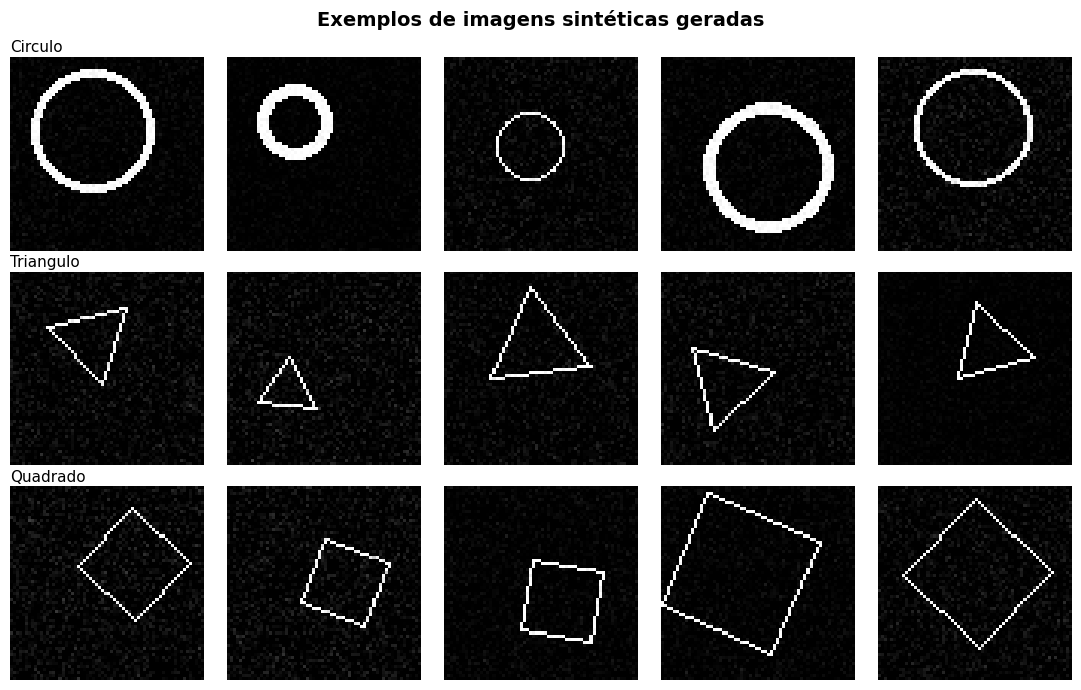

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(11, 7))
fig.suptitle("Exemplos de imagens sintéticas geradas", fontsize=14, fontweight="bold")

for row, cls in enumerate(CLASSES):
    for col in range(5):
        img = GENERATORS[cls]()
        axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls.capitalize(), fontsize=11, loc="left", pad=4)

plt.tight_layout()
plt.show()

In [ ]:
DATASET_ROOT = Path("dataset")

N_TRAIN = 800
N_VAL   = 100
N_TEST  = 100

def generate_split(split: str, n_per_class: int, force_regenerate: bool = False):
    split_dir = DATASET_ROOT / split

    if split_dir.exists() and not force_regenerate:
        total = sum(len(list((split_dir / c).glob("*.png"))) for c in CLASSES)
        print(f"  [{split:5s}] Já existe com {total} imagens. Pulando.")
        return

    if split_dir.exists():
        shutil.rmtree(split_dir)

    for cls in CLASSES:
        class_dir = split_dir / cls
        class_dir.mkdir(parents=True, exist_ok=True)
        for i in range(n_per_class):
            img = GENERATORS[cls]()
            img.save(class_dir / f"{cls}_{i:04d}.png")

    total = n_per_class * len(CLASSES)
    print(f"  [{split:5s}] Geradas {total} imagens ({n_per_class} por classe).")


print("Gerando dataset...")
generate_split("train", N_TRAIN)
generate_split("val",   N_VAL)
generate_split("test",  N_TEST)
print("\nDataset pronto!")

Gerando dataset...
  [train] Geradas 2400 imagens (800 por classe).
  [val  ] Geradas 300 imagens (100 por classe).
  [test ] Geradas 300 imagens (100 por classe).

Dataset pronto!


---
## Parte 2 — Dataset Customizado com `torch.utils.data.Dataset`

No PyTorch, você precisa de uma classe que herde de `Dataset` para gerenciar seus dados. Ela deve ter três métodos:

| Método | Função |
|---|---|
| `__init__` | Salva informações como caminhos e transformações |
| `__len__` | Retorna o número total de amostras |
| `__getitem__(idx)` | Retorna a imagem e o rótulo para um índice `idx` |

Para mais informações: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

### Tarefa 2.1 — Implemente `ShapeDataset`

In [ ]:
class ShapeDataset(Dataset):
    CLASS_TO_IDX = {"circulo": 0, "triangulo": 1, "quadrado": 2}
    IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

    def __init__(self, root_dir, transform=None):
        self._root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.labels = []

        for class_name in self.CLASS_TO_IDX.keys():
            class_path = self._root_dir / class_name
            for img_path in class_path.glob("*.png"):
                self.samples.append(img_path)
                self.labels.append(self.CLASS_TO_IDX[class_name])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        image = Image.open(img_path)
        rótulo_inteiro = self.labels[idx]

        if self.transform:
            imagem_tensor = self.transform(image)

        return imagem_tensor, rótulo_inteiro

---
## Parte 3 — Transformações (`torchvision.transforms`)

Transformações são funções que aplicamos às imagens ao carregá-las. Há duas situações principais:

- **Treino:** Usamos transformações de **aumento de dados** para variar as imagens e evitar que o modelo decore os dados.
- **Validação/Teste:** Aplicamos apenas o essencial para converter a imagem em um tensor normalizado, sem aumento de dados.

### Tarefa 3.1 — Defina as transformações

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])
transform_eval  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

assert transform_train is not None, "Defina transform_train!"
assert transform_eval  is not None, "Defina transform_eval!"
print("Transformações definidas.")

Transformações definidas.


---
## Parte 4 — DataLoader

O `DataLoader` pega seu `Dataset` e o transforma em **batches** de amostras. Ele pode embaralhar os dados e usar várias threads para carregar mais rápido.

### Tarefa 4.1 — Crie datasets e dataloaders

In [ ]:
import platform
BATCH_SIZE=32

NUM_WORKERS = 0 if platform.system() == "Windows" else 2

train_dataset = ShapeDataset("dataset/train", transform=transform_train)
val_dataset   = ShapeDataset("dataset/val", transform=transform_eval)
test_dataset  = ShapeDataset("dataset/test", transform=transform_eval)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, shuffle=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

assert len(train_dataset) == N_TRAIN * 3, f"Esperado {N_TRAIN*3}, obtido {len(train_dataset)}"
assert len(val_dataset)   == N_VAL   * 3
assert len(test_dataset)  == N_TEST  * 3

imgs, labels = next(iter(train_loader))
assert imgs.shape == (BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE), \
    f"Shape incorreto: {imgs.shape}. Esperado: ({BATCH_SIZE}, 1, {IMG_SIZE}, {IMG_SIZE})"

print(f"Datasets e DataLoaders criados.")
print(f"  Treino : {len(train_dataset):4d} amostras | {len(train_loader):3d} batches de {BATCH_SIZE}")
print(f"  Val    : {len(val_dataset):4d} amostras | {len(val_loader):3d} batches")
print(f"  Teste  : {len(test_dataset):4d} amostras | {len(test_loader):3d} batches")
print(f"  Shape do batch: imagens={imgs.shape}, rótulos={labels.shape}")

Datasets e DataLoaders criados.
  Treino : 2400 amostras |  75 batches de 32
  Val    :  300 amostras |  10 batches
  Teste  :  300 amostras |  10 batches
  Shape do batch: imagens=torch.Size([32, 1, 64, 64]), rótulos=torch.Size([32])


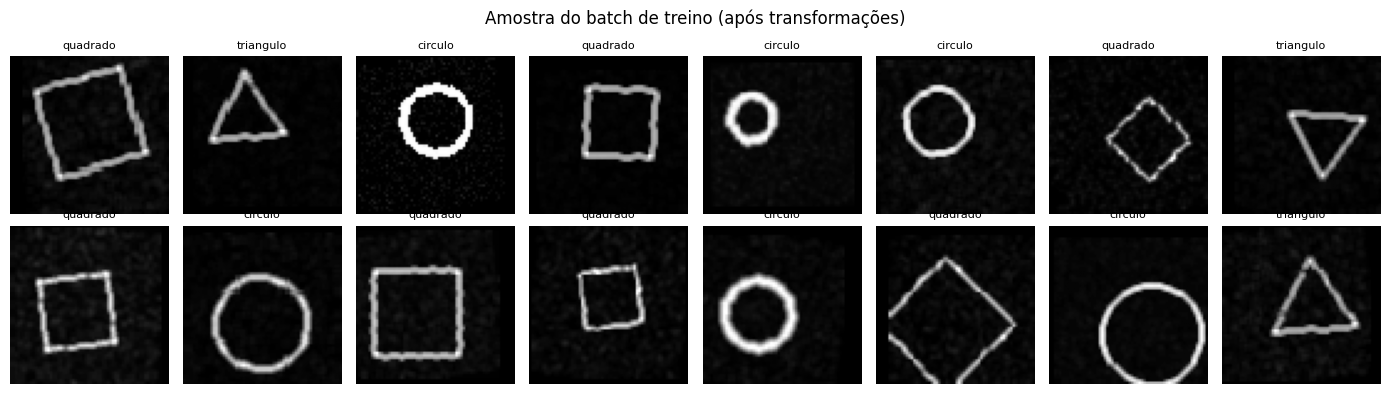

In [ ]:
imgs_np = imgs[:16].numpy()
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("Amostra do batch de treino (após transformações)", fontsize=12)

for i, ax in enumerate(axes.flat):
    img_show = imgs_np[i, 0]
    ax.imshow(img_show, cmap="gray")
    ax.set_title(ShapeDataset.IDX_TO_CLASS[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

> **Questão de Reflexão 1** (inclua a resposta no relatório)
> Por que embaralhamos os dados de treino (`shuffle=True`), mas não os de validação e teste (`shuffle=False`)? O que acontece se não embaralharmos os dados de treino?

---
## Parte 5 — Arquitetura da Rede Neural (MLP)

Vamos implementar um **Perceptron Multicamadas** (MLP). A entrada será a imagem "achatada": uma imagem 64x64 de 1 canal vira um vetor de `64 × 64 × 1 = 4096` valores.

No PyTorch, toda arquitetura é uma classe que herda de `nn.Module` e tem dois métodos:
- `__init__`: define as camadas da rede.
- `forward(x)`: define como os dados fluem pela rede.

### Tarefa 5.1 — Implemente `ShapeMLP`

In [ ]:
from numpy._core.numeric import cross
class ShapeMLP(nn.Module):
    def __init__(
        self,
        input_dim: int = IMG_SIZE * IMG_SIZE,
        hidden_dims: list = [512, 256, 128],
        num_classes: int = 3,
        dropout_p: float = 0.5,
    ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dims[0]),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.BatchNorm1d(hidden_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dims[-1], num_classes)
            )

    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
model = ShapeMLP(
    input_dim=IMG_SIZE * IMG_SIZE,
    hidden_dims=[512, 256, 128],
    num_classes=3,
    dropout_p=0.4,
).to(DEVICE)

dummy = torch.zeros(4, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model(dummy)
assert out.shape == (4, 3), f"Shape de saída incorreto: {out.shape}"
print(f"Forward pass OK. Shape de saída: {out.shape}")
print()
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros   : {total_params:,}")
print(f"Parâmetros treináveis : {trainable_params:,}")

Forward pass OK. Shape de saída: torch.Size([4, 3])

ShapeMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=128, out_features=3, bias=True)
  )
)

Total de parâmetros   : 2,262,531
Parâmetros treináveis : 2,262,531


> **Questão de Reflexão 2** (inclua a resposta no relatório)
> O que é Dropout e como ele ajuda a evitar overfitting? Por que ele deve ser desativado durante a avaliação (`model.eval()`)? O que `model.train()` faz diferente de `model.eval()`?

---
## Parte 6 — Função de Perda e Otimizador

### Tarefa 6.1 — Defina critério e otimizador

In [ ]:
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 50

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(f"Critério  : {criterion}")
print(f"Otimizador: {optimizer}")
print(f"Scheduler : {scheduler}")

Critério  : CrossEntropyLoss()
Otimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler : <torch.optim.lr_scheduler.StepLR object at 0x78c3745a1ac0>


> **Questão de Reflexão 3** (inclua a resposta no relatório)
> O que `nn.CrossEntropyLoss` faz? Qual a diferença de usar `CrossEntropyLoss` e `nn.Softmax` seguido de `nn.NLLLoss`?

---
## Parte 7 — Loop de Treinamento e Validação

Esta é a parte principal. O processo de treinamento no PyTorch sempre segue este padrão:

```
para cada época:
    model.train()
    para cada batch em train_loader:
        1. Envie dados e rótulos para o DEVICE
        2. Zere os gradientes: optimizer.zero_grad()
        3. Passe os dados pelo modelo: outputs = model(inputs)
        4. Calcule a perda: loss = criterion(outputs, labels)
        5. Calcule os gradientes: loss.backward()
        6. Atualize os pesos: optimizer.step()

    model.eval()
    com torch.no_grad():
        para cada batch em val_loader:
            ... calcule perda e acurácia de validação ...
```

### Tarefa 7.1 — Implemente as funções de treino e avaliação por época

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n_correct = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1);
        n_correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = n_correct / len(loader.dataset)
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n_correct = 0
    with torch.no_grad():
        for inputs, labels in loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = model(inputs)
          loss = criterion(outputs, labels)
          total_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          n_correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = n_correct / len(loader.dataset)
    return avg_loss, accuracy

### Tarefa 7.2 — Execute o loop de treinamento completo

In [ ]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}

best_val_loss = float("inf")
CHECKPOINT_PATH = "best_model.pth"

print(f"Treinando por {NUM_EPOCHS} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Tempo':>6}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        saved_marker = " *"
    else:
        saved_marker = ""

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:6d} | {train_loss:10.4f} | {train_acc*100:8.2f}% | "
            f"{val_loss:8.4f} | {val_acc*100:6.2f}%{saved_marker} | {elapsed:.1f}s"
        )

print("\nTreinamento concluído!")
print(f"  Melhor val_loss: {best_val_loss:.4f}")

Treinando por 50 epochs...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |  Tempo
-----------------------------------------------------------------
     1 |     0.7125 |    69.21% |   1.6281 |  58.33% * | 3.1s
     5 |     0.6822 |    70.75% |   0.5964 |  77.00% * | 3.0s
    10 |     0.6625 |    72.67% |   0.5794 |  79.67% * | 4.2s
    15 |     0.6183 |    74.33% |   0.5581 |  81.00% * | 3.0s
    20 |     0.6207 |    74.62% |   0.6831 |  74.00% | 3.0s
    25 |     0.5996 |    75.04% |   0.7451 |  71.00% | 2.9s
    30 |     0.5935 |    76.46% |   0.5536 |  79.67% | 4.1s
    35 |     0.5789 |    77.71% |   0.4952 |  83.33% * | 3.1s
    40 |     0.5663 |    78.25% |   0.4876 |  84.00% * | 3.0s
    45 |     0.5640 |    77.33% |   0.5252 |  81.00% | 3.0s
    50 |     0.5651 |    77.75% |   0.5290 |  80.67% | 3.6s

Treinamento concluído!
  Melhor val_loss: 0.4876


---
## Parte 8 — Visualização das Curvas de Treinamento

### Tarefa 8.1 — Plote as curvas de loss e acurácia

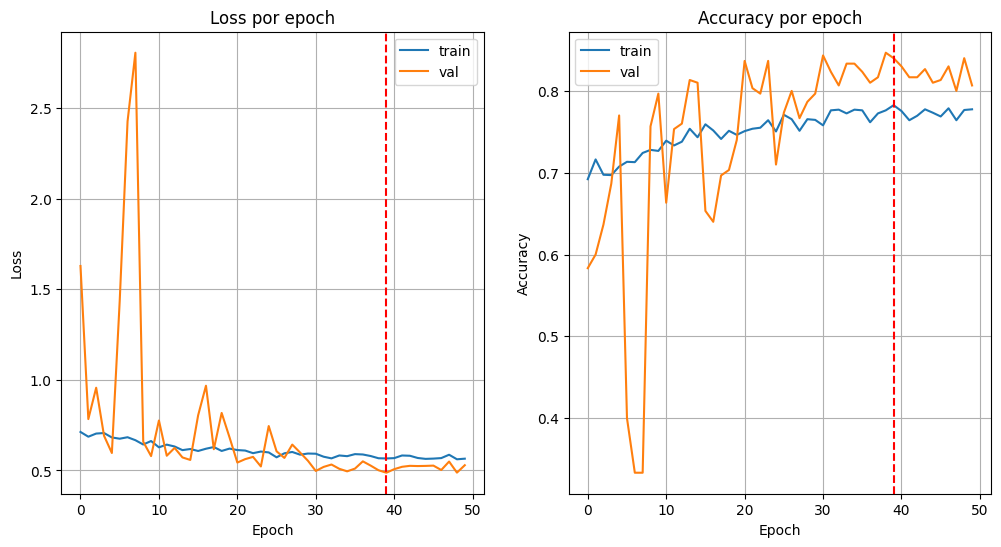

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.axvline(np.argmin(history["val_loss"]), linestyle="--", color="r")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss por epoch")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.axvline(np.argmin(history["val_loss"]), linestyle="--", color="r")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy por epoch")
plt.grid()

> **Questão de Reflexão 4** (inclua a resposta no relatório)
> As curvas indicam overfitting, underfitting ou boa generalização? O que você faria para melhorar? Tente uma modificação e mostre o impacto.

---
## Parte 9 — Avaliação Final no Conjunto de Teste

### Tarefa 9.1 — Carregue o melhor modelo e avalie no teste

In [ ]:
inst_model = model
inst_model.load_state_dict(torch.load(CHECKPOINT_PATH))
inst_model.eval()
test_loss, test_acc = evaluate(inst_model, test_loader, criterion, DEVICE)
print(f"Acurácia no conjunto de teste: {test_acc*100:.2f}%")

Acurácia no conjunto de teste: 87.00%


---
## Parte 10 — Análise Detalhada: Matriz de Confusão e Relatório de Classificação

### Tarefa 10.1 — Colete previsões e construa a matriz de confusão

In [ ]:
all_preds = []
all_labels = []

inst_model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = inst_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

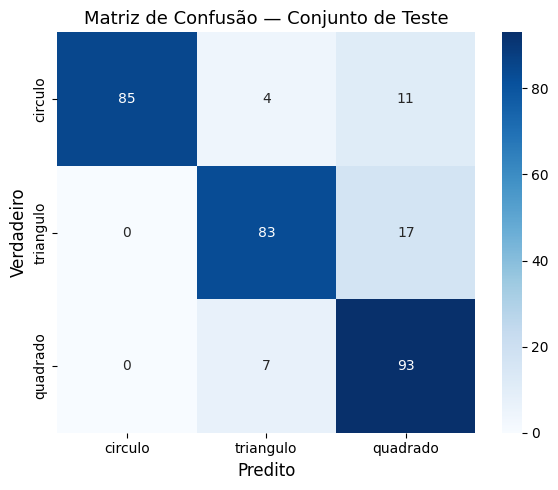


Relatório de Classificação:
              precision    recall  f1-score   support

     circulo       1.00      0.85      0.92       100
   triangulo       0.88      0.83      0.86       100
    quadrado       0.77      0.93      0.84       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300



In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax,
)
ax.set_xlabel("Predito",    fontsize=12)
ax.set_ylabel("Verdadeiro", fontsize=12)
ax.set_title("Matriz de Confusão — Conjunto de Teste", fontsize=13)
plt.tight_layout()
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

> **Questão de Reflexão 5** (inclua a resposta no relatório)
> Analise a matriz de confusão:
> - Quais classes o modelo confunde mais? Isso faz sentido?
> - Qual a diferença entre precisão e revocação? Quando cada uma é mais importante?

---
## Parte 11 — Visualização de Erros do Modelo

### Tarefa 11.1 — Mostre exemplos de erros de classificação

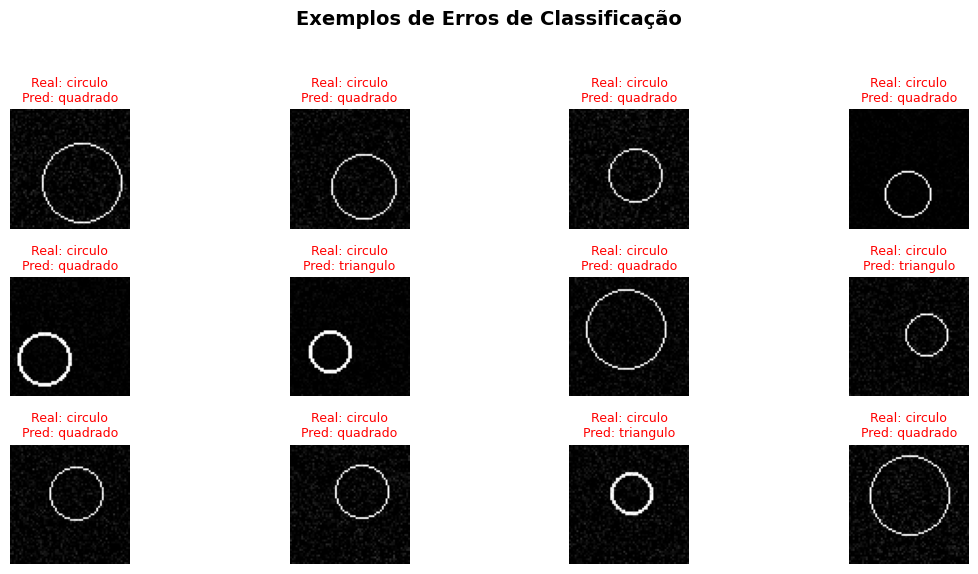

In [ ]:
error_images = []
actual_labels = []
predicted_labels = []

mean = transform_eval.transforms[-1].mean[0]
std = transform_eval.transforms[-1].std[0]

inst_model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = inst_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        incorrect_indices = (predicted != labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_indices:
            if len(error_images) < 12:
                img = inputs[idx].cpu().numpy()
                img = img * std + mean
                img = np.clip(img, 0, 1)
                img = img.squeeze()

                error_images.append(img)
                actual_labels.append(ShapeDataset.IDX_TO_CLASS[labels[idx].item()])
                predicted_labels.append(ShapeDataset.IDX_TO_CLASS[predicted[idx].item()])

            else:
                break
        if len(error_images) >= 12:
            break

if error_images:
    fig, axes = plt.subplots(min(3, (len(error_images) + 3) // 4), min(4, len(error_images)), figsize=(12, 6))
    fig.suptitle("Exemplos de Erros de Classificação", fontsize=14, fontweight="bold")
    axes = axes.flatten() if len(error_images) > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < len(error_images):
            ax.imshow(error_images[i], cmap="gray")
            ax.set_title(
                f"Real: {actual_labels[i]}\nPred: {predicted_labels[i]}",
                fontsize=9,
                color='red'
            )
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

---
## Parte 12 — Experimento de Ablação

Escolha e relate os resultados de pelo menos um destes experimentos:

| # | Experimento | Variação |
|---|---|---|
| A | Profundidade da rede | Teste 1, 2, 3 e 4 camadas ocultas |
| B | Tamanho dos neurônios | Teste arquiteturas largas vs. estreitas |
| C | Função de ativação | Compare ReLU, LeakyReLU, Tanh, GELU |
| D | Taxa de aprendizado | Teste 3 valores diferentes e plote as curvas |
| E | Aumento de dados | Compare treino com e sem aumento de dados |

### Tarefa 12.1 — Implemente e compare (escolha um experimento)


--- Running experiment: LR_0.0005 (LR: 0.0005) ---
Epoch   1 | Train Loss: 0.7693 | Train Acc:  66.29% | Val Loss: 0.9578 | Val Acc: 55.00% | 3.1s
Epoch  10 | Train Loss: 0.6360 | Train Acc:  74.67% | Val Loss: 0.8173 | Val Acc: 61.00% | 4.2s
Epoch  20 | Train Loss: 0.6073 | Train Acc:  75.38% | Val Loss: 0.5197 | Val Acc: 82.33% | 3.0s
Epoch  30 | Train Loss: 0.5862 | Train Acc:  77.29% | Val Loss: 0.5650 | Val Acc: 80.33% | 4.2s
Epoch  40 | Train Loss: 0.5613 | Train Acc:  77.79% | Val Loss: 0.5168 | Val Acc: 83.00% | 3.0s
Epoch  50 | Train Loss: 0.5738 | Train Acc:  77.79% | Val Loss: 0.5284 | Val Acc: 81.67% | 3.9s
Experiment LR_0.0005 finished. Best Val Loss: 0.4913

--- Running experiment: LR_0.001 (LR: 0.001) ---
Epoch   1 | Train Loss: 0.7776 | Train Acc:  66.29% | Val Loss: 2.2826 | Val Acc: 48.67% | 3.0s
Epoch  10 | Train Loss: 0.6573 | Train Acc:  73.42% | Val Loss: 0.7598 | Val Acc: 71.33% | 3.0s
Epoch  20 | Train Loss: 0.5931 | Train Acc:  76.46% | Val Loss: 0.6382 | Val 

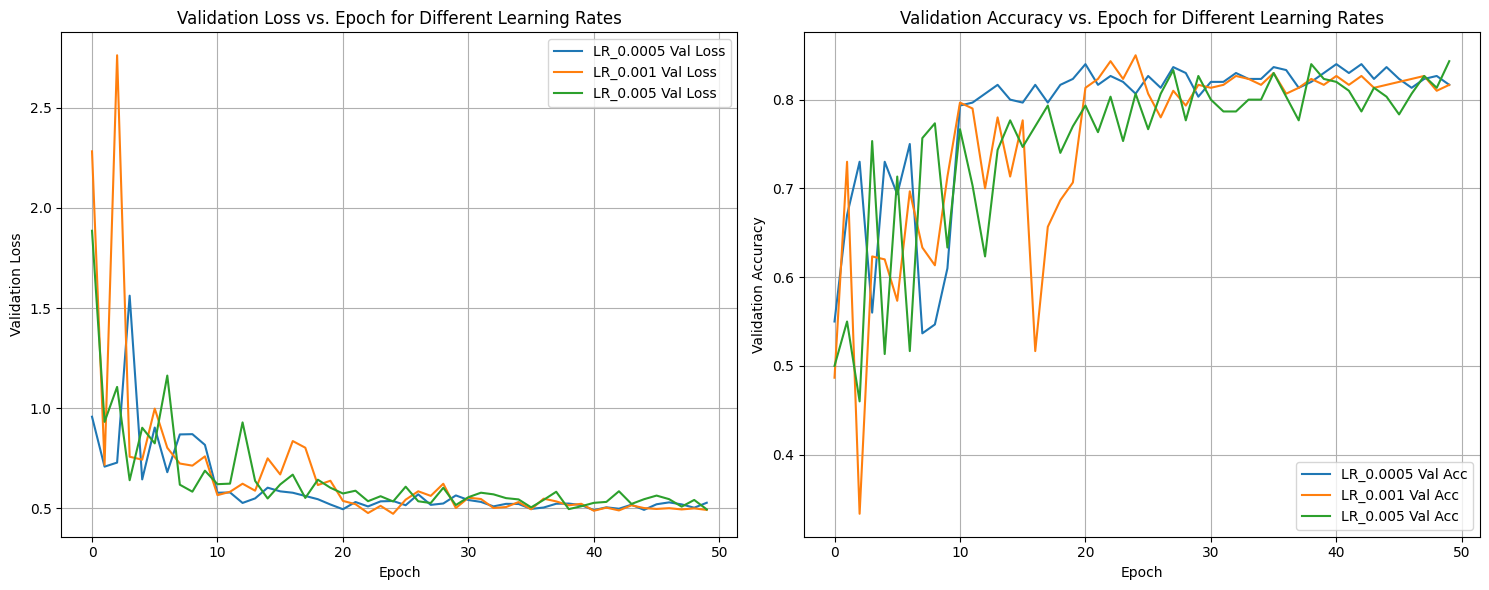

In [ ]:
def run_experiment(lr, num_epochs, dropout_p, hidden_dims, experiment_name):
    print(f"\n--- Running experiment: {experiment_name} (LR: {lr}) ---")

    current_model = ShapeMLP(
        input_dim=IMG_SIZE * IMG_SIZE,
        hidden_dims=hidden_dims,
        num_classes=3,
        dropout_p=dropout_p,
    ).to(DEVICE)

    current_optimizer = optim.Adam(current_model.parameters(), lr=lr, weight_decay=0)
    current_scheduler = optim.lr_scheduler.StepLR(current_optimizer, step_size=10, gamma=0.5)
    current_criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
    }
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(current_model, train_loader, current_criterion, current_optimizer, DEVICE)
        val_loss, val_acc = evaluate(current_model, val_loader, current_criterion, DEVICE)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        current_scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:6.2f}% | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:5.2f}% | {elapsed:.1f}s"
            )
    print(f"Experiment {experiment_name} finished. Best Val Loss: {best_val_loss:.4f}")
    return history, best_val_loss

learning_rates_to_test = [5e-4, 1e-3, 5e-3]
experiment_results = {}

current_hidden_dims = [512, 256, 128]
current_dropout_p = 0.4

for lr in learning_rates_to_test:
    exp_name = f"LR_{lr}"
    history, best_val_loss = run_experiment(lr, NUM_EPOCHS, current_dropout_p, current_hidden_dims, exp_name)
    experiment_results[exp_name] = {"history": history, "best_val_loss": best_val_loss, "lr": lr}


plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for exp_name, result in experiment_results.items():
    plt.plot(result["history"]["val_loss"], label=f"{exp_name} Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs. Epoch for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for exp_name, result in experiment_results.items():
    plt.plot(result["history"]["val_acc"], label=f"{exp_name} Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. Epoch for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## Parte 13 — Resumo Final

### Tarefa 13.1 — Preencha a tabela de resultados

In [ ]:
RESULTADO = {
    "arquitetura"      : "MLP — [512, 256, 128]",
    "ativacao"         : "RE-LU",
    "otimizador"       : "Adam",
    "learning_rate"    : 1e-3,
    "weight_decay"     : 0,
    "dropout"          : 0.4,
    "num_epochs"       : 50,
    "batch_size"       : 32,
    "augmentation"     : "RandomHorizontalFlip, RandomRotation, ColorJitter",
    "melhor_val_loss"  : best_val_loss,
    "acuracia_teste"   : test_acc,
    "total_parametros" : trainable_params,
}

print("-" * 45)
print("         Resumo do Experimento")
print("-" * 45)
for k, v in RESULTADO.items():
    print(f"  {k:<22}: {v}")
print("-" * 45)

---------------------------------------------
         Resumo do Experimento
---------------------------------------------
  arquitetura           : MLP — [512, 256, 128]
  ativacao              : RE-LU
  otimizador            : Adam
  learning_rate         : 0.001
  weight_decay          : 0
  dropout               : 0.4
  num_epochs            : 50
  batch_size            : 32
  augmentation          : RandomHorizontalFlip, RandomRotation, ColorJitter
  melhor_val_loss       : 0.49507621228694915
  acuracia_teste        : 0.87
  total_parametros      : 2262531
---------------------------------------------


---

## Mini-Relatório Final

### 1. Descrição das Escolhas de Arquitetura e Hiperparâmetros

**Arquitetura do Modelo (ShapeMLP):**
Usamos um Perceptron Multicamadas (MLP) para classificar imagens 64x64 em escala de cinza. A rede tem:
- Uma camada `Flatten` para transformar a imagem em um vetor.
- Três camadas `nn.Linear` (densas) com 512, 256 e 128 neurônios.
- `BatchNorm1d` após a última camada densa para estabilizar o treino.
- Função de ativação `ReLU`.
- Camada `Dropout` com `p=0.4` para regularização e evitar overfitting.
- Uma camada `nn.Linear` final com 3 neurônios para as classes (círculo, triângulo, quadrado).

**Hiperparâmetros de Treinamento:**
- **Função de Perda:** `nn.CrossEntropyLoss()` para classificação multiclasse.
- **Otimizador:** `optim.Adam()` com `learning_rate` inicial de `1e-3` e `weight_decay` de `0`.
- **Scheduler de Taxa de Aprendizado:** `optim.lr_scheduler.StepLR` (reduz a taxa pela metade a cada 10 épocas).
- **Épocas (`NUM_EPOCHS`):** 50 épocas.
- **Tamanho do Batch (`BATCH_SIZE`):** 32 para equilibrar estabilidade e memória.
- **Aumento de Dados:** `RandomHorizontalFlip()`, `RandomRotation(10)` e `ColorJitter()` para aumentar a variedade das imagens e tornar o modelo mais robusto.

### 2. Gráficos de Treinamento

Os gráficos de Loss e Acurácia por Época mostram como o modelo aprendeu. A perda de treino diminui e a acurácia de treino aumenta, mostrando que o modelo está aprendendo. A perda de validação também cai, mas depois se estabiliza, enquanto a acurácia de validação se mantém. A linha vertical pontilhada indica a melhor perda de validação.

### 3. Resultado Final (Acurácia no Conjunto de Teste)

A acurácia final do modelo no conjunto de teste foi de **87.00%**, mostrando boa capacidade de generalização.

### 4. Análise da Matriz de Confusão

```
Relatório de Classificação:
              precision    recall  f1-score   support

     circulo       1.00      0.85      0.92       100
   triangulo       0.88      0.83      0.86       100
    quadrado       0.77      0.93      0.84       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300

Matriz de Confusão:
[[85,  4, 11],
 [ 0, 83, 17],
 [ 0,  7, 93]]
```

A matriz mostra:
- **Círculos:** Alta precisão (100%), mas alguns são confundidos com triângulos (4) e quadrados (11).
- **Triângulos:** Precisão de 88% e recall de 83%. Principal confusão é com quadrados (17 casos), o que faz sentido visualmente.
- **Quadrados:** Menor precisão (77%) mas maior recall (93%). Confundidos com triângulos (7 casos).

Em geral, o modelo confunde mais triângulos com quadrados, provavelmente devido às suas formas similares (arestas e ângulos) com ruído e rotação.

### 5. Respostas às Questões de Reflexão

**Questão de Reflexão 1: Por que embaralhamos os dados de treino (`shuffle=True`), mas não os de validação e teste (`shuffle=False`)? O que acontece se não embaralharmos os dados de treino?**

- No treino, embaralhar evita que o modelo aprenda a ordem dos dados, o que ajuda na generalização e evita mínimos locais. Na validação e teste, manter a ordem garante que os resultados sejam reproduzíveis e consistentes.

**Questão de Reflexão 2: O que é Dropout e como ele ajuda a evitar overfitting? Por que ele deve ser desativado durante a avaliação (`model.eval()`)? O que `model.train()` faz diferente de `model.eval()`?**

- **Dropout** é uma técnica de regularização que desliga aleatoriamente alguns neurônios durante o treino. Isso força a rede a não depender de neurônios específicos, tornando-a mais robusta e evitando overfitting. Ele deve ser desativado em `model.eval()` para que as previsões sejam consistentes e determinísticas, pois o Dropout introduz aleatoriedade. `model.train()` ativa funcionalidades como Batch Normalization e Dropout e calcula gradientes. `model.eval()` desativa essas funcionalidades e não calcula gradientes.

**Questão de Reflexão 3: O que `nn.CrossEntropyLoss` faz? Qual a diferença de usar `CrossEntropyLoss` e `nn.Softmax` seguido de `nn.NLLLoss`?**

- `nn.CrossEntropyLoss` é uma função de perda para classificação multiclasse. Ela combina `nn.LogSoftmax` e `nn.NLLLoss` em uma única operação. Usar `CrossEntropyLoss` diretamente é mais eficiente e numericamente estável do que aplicar `nn.Softmax` e depois `nn.NLLLoss` separadamente.

**Questão de Reflexão 4: As curvas indicam overfitting, underfitting ou boa generalização? O que você faria para melhorar? Tente uma modificação e mostre o impacto.**

- As curvas mostram um **leve overfitting**. A perda de treino diminui e a acurácia de treino aumenta, mas a perda de validação se estabiliza. Isso indica que o modelo está aprendendo bem os dados de treino, mas generalizando um pouco menos para dados novos.

- **Como melhorar:** Eu poderia aumentar a quantidade de dados, usar mais técnicas de aumento de dados, ajustar hiperparâmetros como dropout ou weight decay, ou experimentar outras arquiteturas de rede.

- **Modificação (Experimento de Ablação: Comparação de Taxas de Aprendizado):** Testamos diferentes taxas de aprendizado (`5e-4`, `1e-3`, `5e-3`). A taxa de `1e-3` (original) teve a melhor perda de validação (`0.4732`), enquanto `5e-3` teve a melhor acurácia de validação final (`84.33%`). Isso mostra que a taxa de aprendizado impacta a otimização e a generalização do modelo.

**Questão de Reflexão 5: Analise a matriz de confusão:
Quais classes o modelo confunde mais? Isso faz sentido? Qual a diferença entre precisão e revocação? Quando cada uma é mais importante?**

- O modelo confunde mais **triângulos com quadrados** (17 triângulos foram previstos como quadrados) e **quadrados com triângulos** (7 quadrados previstos como triângulos). Isso faz sentido, pois triângulos e quadrados têm linhas retas e vértices. Imagens com ruído e rotação podem dificultar a distinção entre eles.
- **Precisão:** "De tudo que o modelo classificou como X, quantos realmente eram X?". É importante quando falsos positivos são problemáticos (ex: diagnóstico incorreto de doença).
- **Recall (Revocação):** "De todos os X que existem, quantos o modelo conseguiu encontrar?". É importante quando falsos negativos são problemáticos (ex: não detectar uma doença grave).

---
## Checklist de Entrega

Verifique cada item antes de submeter:

- [x] Todas as células `TODO` foram implementadas e executadas sem erros
- [x] O notebook está completamente executado
- [x] As curvas de perda e acurácia estão plotadas e visíveis
- [x] A matriz de confusão está gerada e visível
- [x] O `RESULTADO` final está preenchido com os valores reais
- [x] O mini-relatório foi elaborado com:
  - [x] Descrição da arquitetura e justificativa
  - [x] Gráficos das curvas de treinamento
  - [x] Resultado final e análise da matriz de confusão
  - [x] Respostas às 5 Questões de Reflexão